## Libraries

In [9]:
import pandas as pd
import numpy as np
import os
import spacy
from dotenv import load_dotenv
from pprint import pprint
import seaborn as sns
import matplotlib.pyplot as plt

from src.summary_destructor import SummaryDestructor

load_dotenv()
ANNUAL_REPORTS_DIR = os.getenv('ANNUAL_REPORTS_DIR')
GOLD_SUMMARIES_DIR = os.getenv('GOLD_SUMMARIES_DIR')
CANDIDATE_SUMMARIES_DIR = os.getenv('CANDIDATE_SUMMARIES_DIR')
RESULTS_PATH = os.getenv('RESULTS_PATH')

## Candidate summaries

### Abstractive summaries with a summarization model

In [6]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("kriton/greek-text-summarization")
model = AutoModelForSeq2SeqLM.from_pretrained("kriton/greek-text-summarization")

In [7]:
def get_token_length(filepath):
    with open(filepath, mode='r', encoding='utf-8') as file:
        text = file.read()
    return len(tokenizer(text, truncation=False, padding=False)['input_ids'])

In [8]:
source_token_lengths = [
    get_token_length(ANNUAL_REPORTS_DIR+txtfile)
    for txtfile in os.listdir(ANNUAL_REPORTS_DIR)
]

goldsum_token_lengths = [
    get_token_length(GOLD_SUMMARIES_DIR+txtfile)
    for txtfile in os.listdir(GOLD_SUMMARIES_DIR)    
]

In [9]:
max_input_token_length = max(source_token_lengths)
min_output_token_length = min(goldsum_token_lengths)
max_output_token_length = max(goldsum_token_lengths)

In [10]:
print(max_input_token_length)
print(min_output_token_length)
print(max_output_token_length)

582189
1
159722


In [ ]:
from transformers import pipeline

summarizer = pipeline("summarization", model="kriton/greek-text-summarization")

def genarate_summary(article):
    inputs = tokenizer(
        'summarize: ' + article, 
        return_tensors="pt", 
        max_length=max_input_token_length, 
        truncation=True,
        padding="max_length",
    )

    outputs = model.generate(
        inputs["input_ids"], 
        max_length=max_output_token_length, 
        min_length=min_output_token_length, 
        length_penalty=3.0,
        num_beams=8, 
        early_stopping=True,
        repetition_penalty=3.0,
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

Device set to use cuda:0


In [24]:
for txtfile in os.listdir(ANNUAL_REPORTS_DIR)[:1]:
    with open(ANNUAL_REPORTS_DIR+txtfile, mode='r', encoding='utf-8') as file:
        source = file.read()
        print(genarate_summary(article=source))

Σημαντικά γεγονότα της χρήσης για το έτος που έληξε την 31η Δεκεμβρίου 2019 (Σύμφωνα με το Ν.3556/07) Ο Αναπληρωτής Διευθύνων Σύμβουλος Μάρκος Μπιτσάκος αναφέρει: Ετήσια Οικονομική Έκθεση της 31 Δεκεμβρίου 2019 (Τα ποσά παρουσιάζονται σε χιλιάδες Ευρώ εκτός εάν δηλώνεται διαφορετικά) δ


### Reduced gold summaries as candidate summaries

In [45]:
nlp = spacy.load('el_core_news_sm')
nlp.add_pipe('sentencizer', before='parser')

In [2]:
gold_summary =  open(os.path.join(GOLD_SUMMARIES_DIR,'1_1.txt'), mode='r', encoding='utf-8').read()
destructor = SummaryDestructor(input_summary=gold_summary)
pprint(gold_summary)

2025-03-10 16:31:53.674 | INFO     | src.summary_destructor:__init__:34 - SummaryDestructor initialized.


('Τα μέλη του Διοικητικού Συμβουλίου, κ.κ. Θεόδωρος Φέσσας, Πρόεδρος, '
 'Απόστολος Γεωργαντζής, Διευθύνων\n'
 'Σύμβουλος και Μάρκος Μπιτσάκος, Αναπληρωτής Διευθύνων Σύμβουλος , υπό την ως '
 'άνω ιδιότητά τους, δηλώνουν\n'
 'ότι, εξ όσων γνωρίζουν :\n'
 '\uf0b7\n'
 '\n'
 'Οι συνημμένες ετήσιες εταιρικές και ενοποιημένες Χρηματοοικονομικές '
 'Καταστάσεις της Quest Συμμετοχών\n'
 'A.E. (η Εταιρεία), οι οποίες καταρτίσθηκαν για τη χρήση 1/1-31/12/2019, '
 'σύμφωνα με τα Διεθνή Πρότυπα\n'
 'Χρηματοοικονομικής Αναφοράς, απεικονίζουν κατά τρόπο αληθή τα στοιχεία του '
 'ενεργητικού και του\n'
 'παθητικού, την καθαρή θέση και τα αποτελέσματα χρήσης της Εταιρείας, καθώς '
 'και των εταιρειών που\n'
 'περιλαμβάνονται στην ενοποίηση εκλαμβανομένων ως σύνολο (ο Όμιλος).\n'
 '\n'
 '\uf0b7\n'
 '\n'
 'Η συνημμένη έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπον αληθή '
 'την εξέλιξη, τις επιδόσεις\n'
 'και τη θέση της Εταιρείας, καθώς και του Ομίλου, συμπεριλαμβανομένης της '
 'περιγραφής

In [41]:
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize

pprint(sent_tokenize(text=gold_summary, language='greek')[2])

('(η Εταιρεία), οι οποίες καταρτίσθηκαν για τη χρήση 1/1-31/12/2019, σύμφωνα '
 'με τα Διεθνή Πρότυπα\n'
 'Χρηματοοικονομικής Αναφοράς, απεικονίζουν κατά τρόπο αληθή τα στοιχεία του '
 'ενεργητικού και του\n'
 'παθητικού, την καθαρή θέση και τα αποτελέσματα χρήσης της Εταιρείας, καθώς '
 'και των εταιρειών που\n'
 'περιλαμβάνονται στην ενοποίηση εκλαμβανομένων ως σύνολο (ο Όμιλος).')


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Stefania\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [44]:
doc = nlp(gold_summary)
sentences = [sent.text.strip() for sent in doc.sents]
pprint(sentences[0])

('Τα μέλη του Διοικητικού Συμβουλίου, κ.κ. Θεόδωρος Φέσσας, Πρόεδρος, '
 'Απόστολος Γεωργαντζής, Διευθύνων\n'
 'Σύμβουλος και Μάρκος Μπιτσάκος, Αναπληρωτής Διευθύνων Σύμβουλος , υπό την ως '
 'άνω ιδιότητά τους, δηλώνουν\n'
 'ότι, εξ όσων γνωρίζουν :\n'
 '\uf0b7\n'
 '\n'
 'Οι συνημμένες ετήσιες εταιρικές και ενοποιημένες Χρηματοοικονομικές '
 'Καταστάσεις της Quest Συμμετοχών\n'
 'A.E. (η Εταιρεία), οι οποίες καταρτίσθηκαν για τη χρήση 1/1-31/12/2019, '
 'σύμφωνα με τα Διεθνή Πρότυπα\n'
 'Χρηματοοικονομικής Αναφοράς, απεικονίζουν κατά τρόπο αληθή τα στοιχεία του '
 'ενεργητικού και του\n'
 'παθητικού, την καθαρή θέση και τα αποτελέσματα χρήσης της Εταιρείας, καθώς '
 'και των εταιρειών που\n'
 'περιλαμβάνονται στην ενοποίηση εκλαμβανομένων ως σύνολο (ο Όμιλος).')


#### Randomly swap words

In [41]:
pprint(destructor.random_swap_words(summary_perc=0.9))

('Τα Διοικητικού του μέλη κ.κ. Συμβουλίου, Φέσσας, Θεόδωρος Απόστολος '
 'Πρόεδρος, Διευθύνων Γεωργαντζής, και Σύμβουλος Μπιτσάκος, Μάρκος Αναπληρωτής '
 'Σύμβουλος Διευθύνων υπό , ως την ιδιότητά άνω δηλώνουν τους, εξ ότι, Οι '
 'γνωρίζουν : \uf0b7 όσων ετήσιες συνημμένες και εταιρικές Χρηματοοικονομικές '
 'ενοποιημένες της Καταστάσεις Quest A.E. Συμμετοχών Εταιρεία), (η οποίες οι '
 'για καταρτίσθηκαν χρήση τη σύμφωνα 1/1-31/12/2019, τα με Πρότυπα Διεθνή '
 'Αναφοράς, Χρηματοοικονομικής κατά απεικονίζουν αληθή τρόπο στοιχεία τα και '
 'ενεργητικού του παθητικού, του καθαρή την και θέση αποτελέσματα τα της '
 'χρήσης των καθώς και Εταιρείας, που εταιρειών στην περιλαμβάνονται '
 'εκλαμβανομένων ενοποίηση σύνολο ως Όμιλος). (ο Η \uf0b7 έκθεση συνημμένη '
 'Διοικητικού του απεικονίζει Συμβουλίου τρόπον κατά την αληθή εξέλιξη, '
 'επιδόσεις τις τη και της θέση καθώς Εταιρείας, του και περιγραφής '
 'συμπεριλαμβανομένης της Ομίλου, κυριότερων των και κινδύνων που αβεβαιοτήτων '
 'Καλλιθέ

#### Randomly remove words

In [4]:
pprint(destructor.remove_words(summary_perc=0.9))

('Μπιτσάκος, , καταρτίσθηκαν 1/1-31/12/2019, Διεθνή ενεργητικού \uf0b7 του '
 'απεικονίζει την επιδόσεις και του και Ο')


#### Randomly remove sentences

In [5]:
pprint(destructor.remove_sentence(summary_perc=0.9))

('\uf0b7\n'
 '\n'
 'Η συνημμένη έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπον αληθή '
 'την εξέλιξη, τις επιδόσεις\n'
 'και τη θέση της Εταιρείας, καθώς και του Ομίλου, συμπεριλαμβανομένης της '
 'περιγραφής των κυριότερων\n'
 'κινδύνων και αβεβαιοτήτων που αντιμετωπίζουν.')


#### Insert sentences from other summaries

In [ ]:
source_docs = [file[:-4] for file in os.listdir(ANNUAL_REPORTS_DIR)]

pprint(destructor.insert_sentence(target='1', source_docs=source_docs, gold_dir=GOLD_SUMMARIES_DIR, summary_perc=0.9))

('Τα μέλη του Διοικητικού Συμβουλίου, κ.κ. Θεόδωρος Φέσσας, Πρόεδρος, '
 'Απόστολος Γεωργαντζής, Διευθύνων\n'
 'Σύμβουλος και Μάρκος Μπιτσάκος, Αναπληρωτής Διευθύνων Σύμβουλος , υπό την ως '
 'άνω ιδιότητά τους, δηλώνουν\n'
 'ότι, εξ όσων γνωρίζουν :\n'
 '\uf0b7\n'
 '\n'
 'Οι συνημμένες ετήσιες εταιρικές και ενοποιημένες Χρηματοοικονομικές '
 'Καταστάσεις της Quest Συμμετοχών\n'
 'A.E. (η Εταιρεία), οι οποίες καταρτίσθηκαν για τη χρήση 1/1-31/12/2019, '
 'σύμφωνα με τα Διεθνή Πρότυπα\n'
 'Χρηματοοικονομικής Αναφοράς, απεικονίζουν κατά τρόπο αληθή τα στοιχεία του '
 'ενεργητικού και του\n'
 'παθητικού, την καθαρή θέση και τα αποτελέσματα χρήσης της Εταιρείας, καθώς '
 'και των εταιρειών που\n'
 'περιλαμβάνονται στην ενοποίηση εκλαμβανομένων ως σύνολο (ο Όμιλος).\uf0b7\n'
 '\n'
 'Η συνημμένη έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπον αληθή '
 'την εξέλιξη, τις επιδόσεις\n'
 'και τη θέση της Εταιρείας, καθώς και του Ομίλου, συμπεριλαμβανομένης της '
 'περιγραφής των κυριότε

#### Repeat the same sentence

In [8]:
pprint(destructor.repeat_sentence(summary_perc=0.9))

('Τα μέλη του Διοικητικού Συμβουλίου, κ.κ. Θεόδωρος Φέσσας, Πρόεδρος, '
 'Απόστολος Γεωργαντζής, Διευθύνων\n'
 'Σύμβουλος και Μάρκος Μπιτσάκος, Αναπληρωτής Διευθύνων Σύμβουλος , υπό την ως '
 'άνω ιδιότητά τους, δηλώνουν\n'
 'ότι, εξ όσων γνωρίζουν :\n'
 '\uf0b7\n'
 '\n'
 'Οι συνημμένες ετήσιες εταιρικές και ενοποιημένες Χρηματοοικονομικές '
 'Καταστάσεις της Quest Συμμετοχών\n'
 'A.E. (η Εταιρεία), οι οποίες καταρτίσθηκαν για τη χρήση 1/1-31/12/2019, '
 'σύμφωνα με τα Διεθνή Πρότυπα\n'
 'Χρηματοοικονομικής Αναφοράς, απεικονίζουν κατά τρόπο αληθή τα στοιχεία του '
 'ενεργητικού και του\n'
 'παθητικού, την καθαρή θέση και τα αποτελέσματα χρήσης της Εταιρείας, καθώς '
 'και των εταιρειών που\n'
 'περιλαμβάνονται στην ενοποίηση εκλαμβανομένων ως σύνολο (ο Όμιλος).\uf0b7\n'
 '\n'
 'Η συνημμένη έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπον αληθή '
 'την εξέλιξη, τις επιδόσεις\n'
 'και τη θέση της Εταιρείας, καθώς και του Ομίλου, συμπεριλαμβανομένης της '
 'περιγραφής των κυριότε

In [ ]:
gold_summary.close()

## Analysis

In [2]:
df = pd.read_csv('src/evaluation_results.csv')

In [4]:
df.sort_values(by='source_doc')

,source_doc,eval_type,eval_method,variant,score
0,1,N-gram,Rouge1,source,1.000000
156,1,N-gram,Rouge1,repeated_sentence_0.1,1.000000
157,1,N-gram,Rouge2,repeated_sentence_0.1,1.000000
158,1,Graph-based,AutoSummENG,repeated_sentence_0.1,0.988718
159,1,Graph-based,MeMoG,repeated_sentence_0.1,0.988718
...,...,...,...,...,...
37972,277,Meta,NPowER,inserted_sentence_0.7,0.520258
37973,277,Embeddings-based,BERTScore,inserted_sentence_0.7,1.000000
37974,277,N-gram,Rouge1,inserted_sentence_0.9,0.837209
37976,277,Graph-based,AutoSummENG,inserted_sentence_0.9,0.754724


In [5]:
df['variant_type'] = df['variant']
df.loc[df['variant'].str.endswith('_1'), 'variant_type'] = 'random_summary'

In [11]:
df.loc[:, 'noise_percentage'] = df.loc[df['variant_type'].str[-1:].str.isdigit(), 'variant_type'].str[-3:]
df.loc[df['variant_type'] == 'source', 'noise_percentage'] = '0.0'
df.loc[df['variant_type'].str[-1:].str.isdigit(), 'variant_type'] = df.loc[df['variant_type'].str[-1:].str.isdigit(), 'variant_type'].str[:-4]

In [188]:
df[(df['variant_type'] == 'randomly_swapped_words') & (df['eval_method'] == 'MeMoG')]['score'].describe()

count    1060.000000
mean        0.790815
std         0.048096
min         0.521606
25%         0.755247
50%         0.780871
75%         0.822539
max         0.902549
Name: score, dtype: float64

In [39]:
df[(df['variant_type'] == 'randomly_swapped_words') & (df['eval_method'] == 'AutoSummENG')]['score'].describe()

count    1060.000000
mean        0.790815
std         0.048096
min         0.521606
25%         0.755247
50%         0.780871
75%         0.822539
max         0.902549
Name: score, dtype: float64

### Randomly swapped words

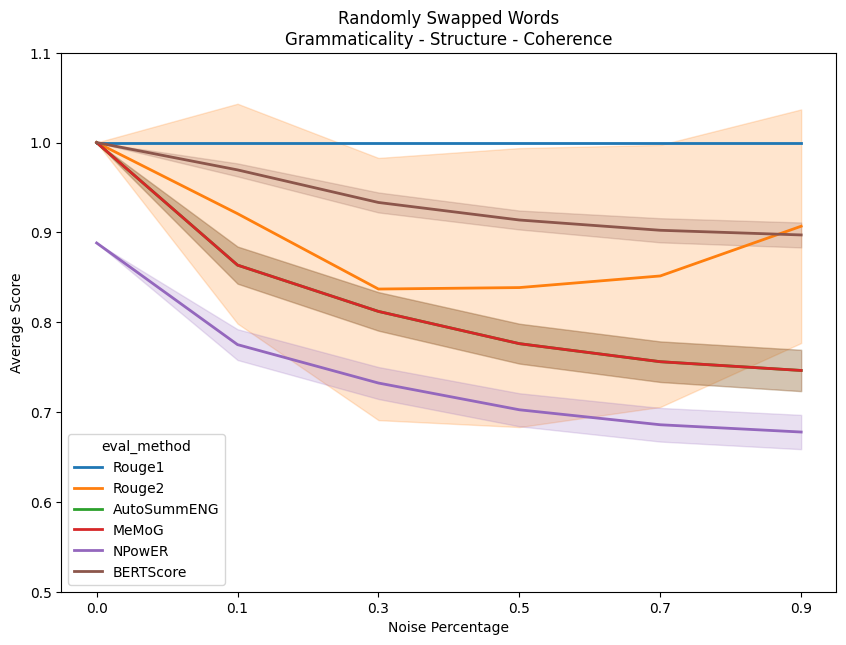

In [23]:
plt.figure(figsize=(10, 7))
sns.lineplot(
    data=df[(df['variant_type'] == 'randomly_swapped_words') | (df['variant_type'] == 'source')],
    x='noise_percentage', 
    y='score',
    hue='eval_method', 
    linewidth=2, 
    estimator=np.mean,
    errorbar='sd'
)

plt.title('Randomly Swapped Words\nGrammaticality - Structure - Coherence')
plt.ylabel('Average Score')
plt.xlabel('Noise Percentage')
plt.yticks(ticks=np.arange(0.5, 1.1, step=0.1))
plt.show()

### Consecutively swapped words

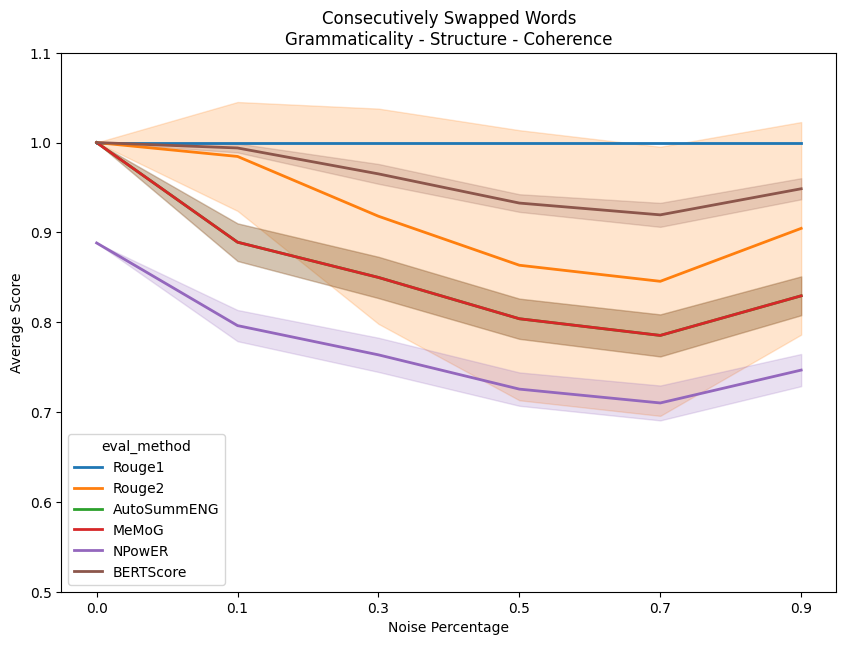

In [24]:
plt.figure(figsize=(10, 7))
sns.lineplot(
    data=df[(df['variant_type'] == 'consecutively_swapped_words') | (df['variant_type'] == 'source')],
    x='noise_percentage', 
    y='score',
    hue='eval_method', 
    linewidth=2, 
    estimator=np.mean,
    errorbar='sd'
)

plt.title('Consecutively Swapped Words\nGrammaticality - Structure - Coherence')
plt.ylabel('Average Score')
plt.xlabel('Noise Percentage')
plt.yticks(ticks=np.arange(0.5, 1.1, step=0.1))
plt.show()

### Removed words

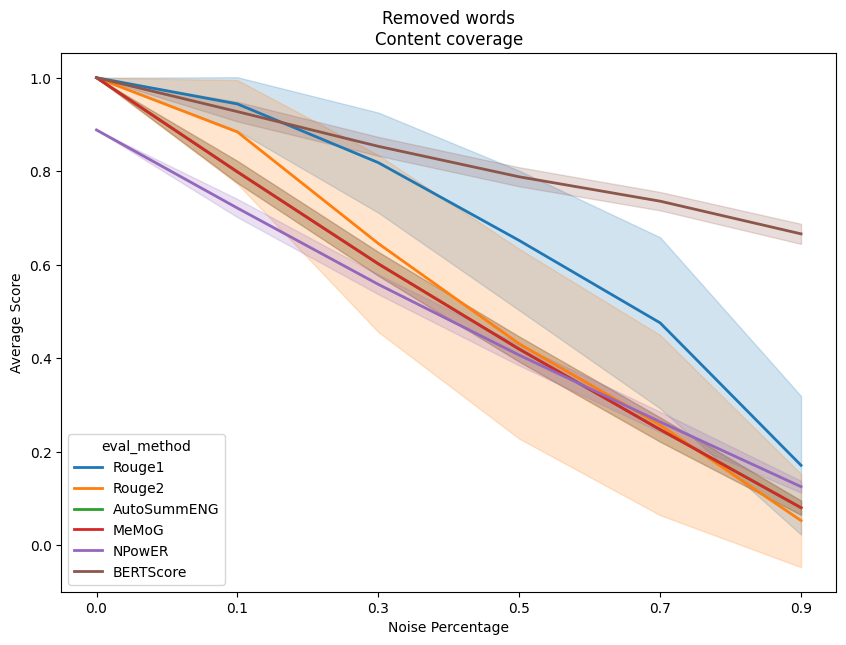

In [37]:
plt.figure(figsize=(10, 7))
sns.lineplot(
    data=df[(df['variant_type'] == 'deleted_words') | (df['variant_type'] == 'source')],
    x='noise_percentage', 
    y='score',
    hue='eval_method', 
    linewidth=2, 
    estimator=np.mean,
    errorbar='sd'
)

plt.title('Removed words\nContent coverage')
plt.ylabel('Average Score')
plt.xlabel('Noise Percentage')
plt.yticks(ticks=np.arange(0.0, 1.1, step=0.2))
plt.show()

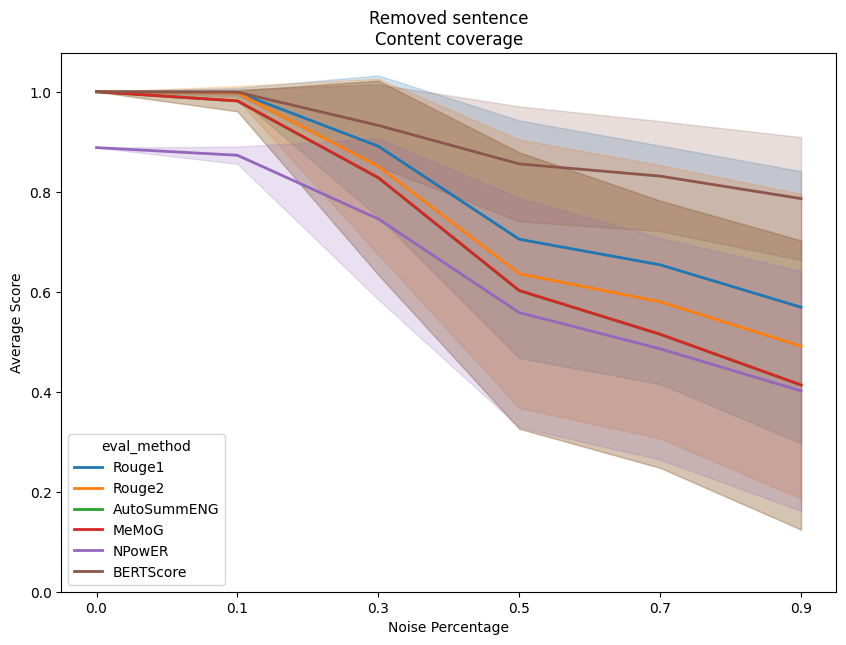

In [26]:
plt.figure(figsize=(10, 7))
sns.lineplot(
    data=df[(df['variant_type'] == 'removed_sentence') | (df['variant_type'] == 'source')],
    x='noise_percentage', 
    y='score',
    hue='eval_method', 
    linewidth=2, 
    estimator=np.mean,
    errorbar='sd'
)

plt.title('Removed sentence\nContent coverage')
plt.ylabel('Average Score')
plt.xlabel('Noise Percentage')
plt.yticks(ticks=np.arange(0.0, 1.1, step=0.2))
plt.show()

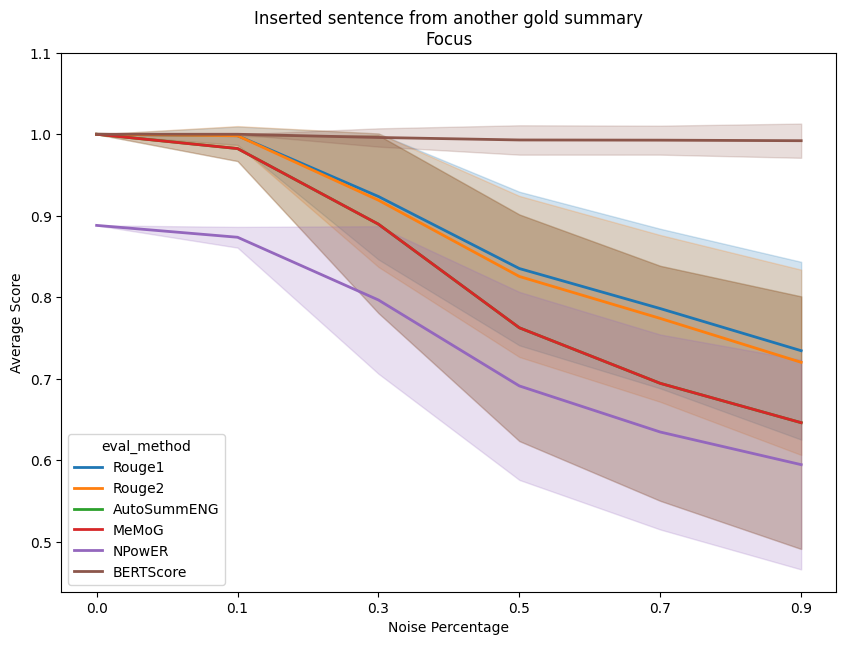

In [27]:
plt.figure(figsize=(10, 7))
sns.lineplot(
    data=df[(df['variant_type'] == 'inserted_sentence') | (df['variant_type'] == 'source')],
    x='noise_percentage', 
    y='score',
    hue='eval_method', 
    linewidth=2, 
    estimator=np.mean,
    errorbar='sd'
)

plt.title('Inserted sentence from another gold summary\nFocus')
plt.ylabel('Average Score')
plt.xlabel('Noise Percentage')
plt.yticks(ticks=np.arange(0.5, 1.1, step=0.1))
plt.show()

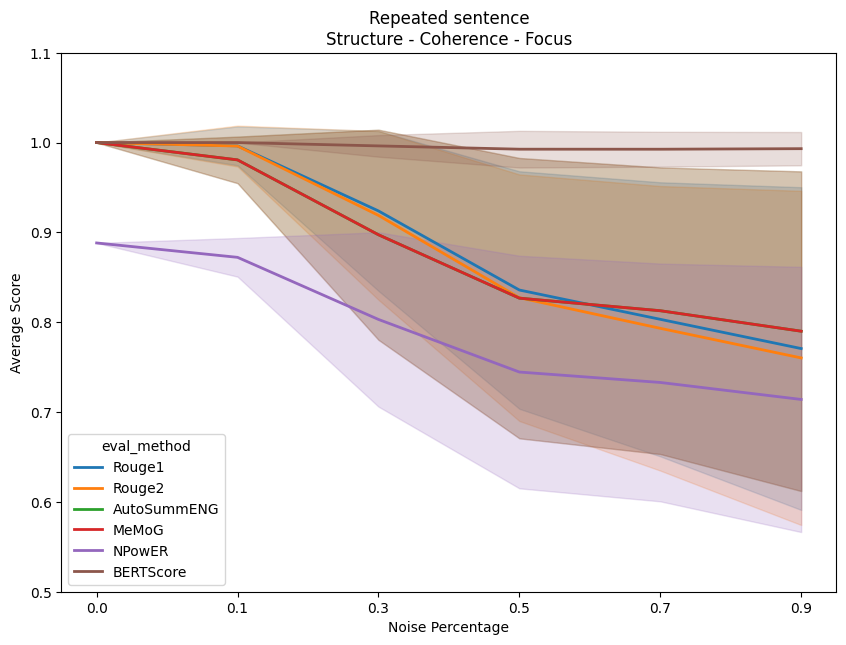

In [35]:
plt.figure(figsize=(10, 7))
sns.lineplot(
    data=df[(df['variant_type'] == 'repeated_sentence') | (df['variant_type'] == 'source')],
    x='noise_percentage', 
    y='score',
    hue='eval_method', 
    linewidth=2, 
    estimator=np.mean,
    errorbar='sd'
)

plt.title('Repeated sentence\nStructure - Coherence - Focus')
plt.ylabel('Average Score')
plt.xlabel('Noise Percentage')
plt.yticks(ticks=np.arange(0.5, 1.1, step=0.1))
plt.show()

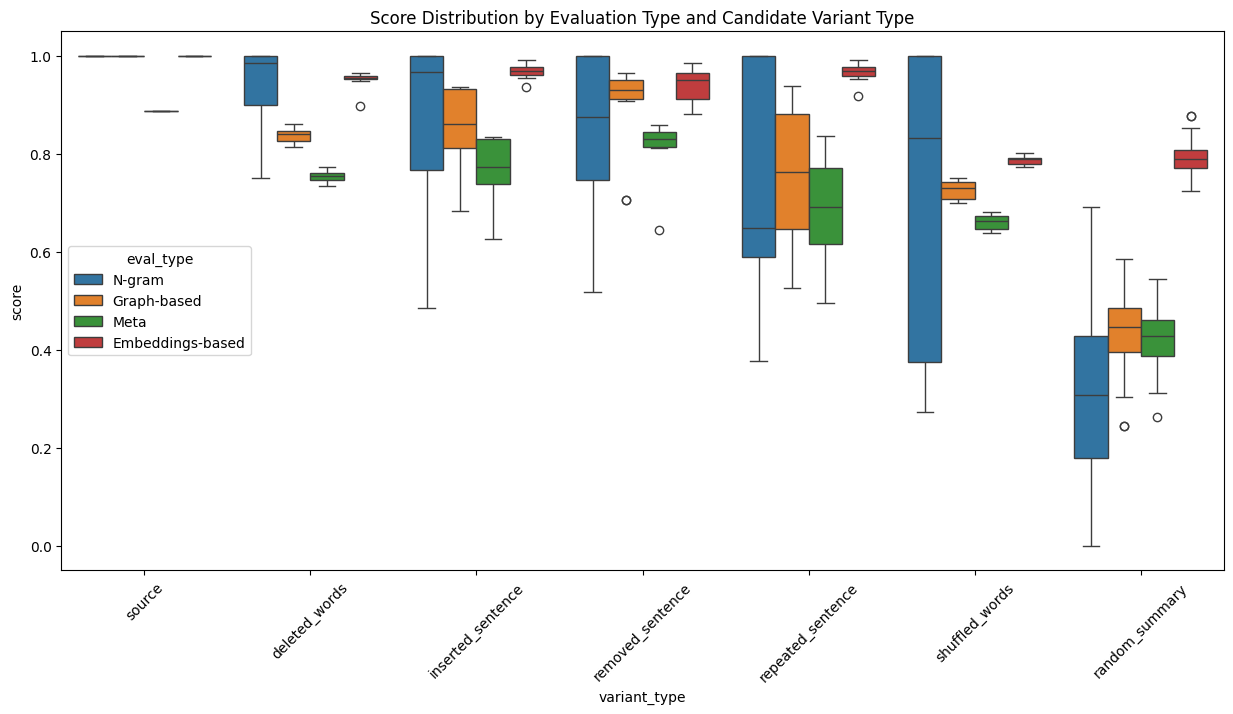

In [87]:
plt.figure(figsize=(15, 7))
sns.boxplot(data=df, x='variant_type', y='score', hue='eval_type')
plt.title('Score Distribution by Evaluation Type and Candidate Variant Type')
plt.xticks(rotation=45)
plt.show()

In [48]:
df_summary = df.groupby(['eval_type', 'variant_type'])['score'].describe().reset_index().drop(columns='count')

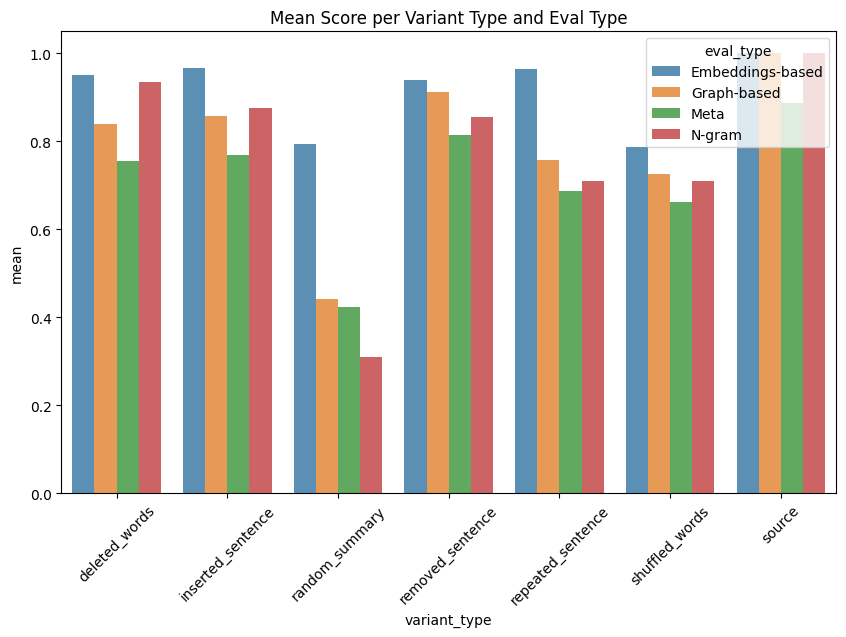

In [88]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_summary, x='variant_type', y='mean', hue='eval_type', alpha=0.8, errorbar=None)
plt.title('Mean Score per Variant Type and Eval Type')
plt.xticks(rotation=45)
plt.show()